# Bayesian Parameter Estimation for Multivariate Bernoulli Distributions

This notebook demonstrates Maximum Likelihood (ML) and Maximum A Posteriori (MAP) estimation for binary data using Beta priors.

## 1. Motivation

When learning parameters of probabilistic models from data, we face a fundamental trade-off:

- **Maximum Likelihood (ML)**: Maximize P(Data | Parameters)
  - Simple, unbiased, but can overfit with limited data
  - Assigns probability 0 to unseen events

- **Maximum A Posteriori (MAP)**: Maximize P(Parameters | Data) ∝ P(Data | Parameters) × P(Parameters)
  - Incorporates prior knowledge
  - Provides regularization against overfitting
  - More robust with small datasets

For Bernoulli parameters, Beta priors are conjugate, making MAP estimation analytically tractable.

## 2. Mathematical Background

### Bernoulli Distribution
For binary variable x ∈ {0,1} with parameter p:
$$P(x|p) = p^x(1-p)^{1-x}$$

### ML Estimation
For dataset X = {x₁, ..., xₙ} with D dimensions:
$$\hat{p}_d^{ML} = \frac{1}{N}\sum_{n=1}^{N} x_{nd}$$

### MAP Estimation with Beta Prior
Prior: $P(p_d) = \text{Beta}(p_d | \alpha, \beta)$

MAP estimate:
$$\hat{p}_d^{MAP} = \frac{\sum_{n} x_{nd} + \alpha - 1}{N + \alpha + \beta - 2}$$

Special cases:
- α = β = 1 (uniform prior): Equivalent to ML
- α = β = 3: Preference for p ≈ 0.5 (regularization)
- Larger α, β: Stronger regularization

## 3. Implementation

In [1]:
import numpy as np
import plotly.io as pio
import os, sys
sys.path.insert(0, os.path.join(os.path.dirname(os.path.abspath('.')), ''))
sys.path.insert(0, os.path.abspath('..'))

# Render Plotly figures as static PNGs (renders on GitHub); remove for interactive mode
pio.renderers.default = "png"

from src.bayesian_inference import (
    compute_ml, compute_map, visualize_parameters,
    compare_ml_map, compare_ml_map_sidebyside
)

In [2]:
# Load binary digit data
X = np.loadtxt('../data/binarydigits.txt')
print(f"Dataset shape: {X.shape}")
print(f"Data type: Binary (0/1)")
print(f"Interpretation: {X.shape[0]} samples of 8×8 binary images")

Dataset shape: (100, 64)
Data type: Binary (0/1)
Interpretation: 100 samples of 8×8 binary images


## 4. Maximum Likelihood Estimation

In [3]:
# Compute ML estimate
ml_params = compute_ml(X)

print("ML Parameter Statistics:")
print(f"  Mean: {np.mean(ml_params):.4f}")
print(f"  Std:  {np.std(ml_params):.4f}")
print(f"  Min:  {np.min(ml_params):.4f}")
print(f"  Max:  {np.max(ml_params):.4f}")

ML Parameter Statistics:
  Mean: 0.3898
  Std:  0.1973
  Min:  0.0000
  Max:  0.7900


## 5. MAP Estimation with Beta(3,3) Prior

MAP Parameter Statistics (α=3, β=3):
  Mean: 0.3941
  Std:  0.1897
  Min:  0.0192
  Max:  0.7788


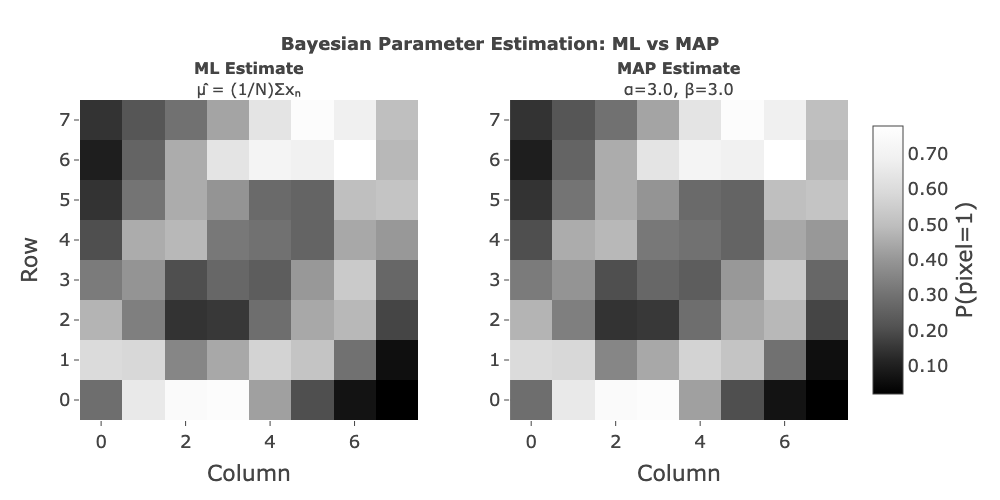


Saved to ../results/figures/ml_vs_map_comparison.png


In [4]:
# Compute MAP estimate with α=3, β=3
map_params = compute_map(X, alpha=3.0, beta=3.0)

print("MAP Parameter Statistics (α=3, β=3):")
print(f"  Mean: {np.mean(map_params):.4f}")
print(f"  Std:  {np.std(map_params):.4f}")
print(f"  Min:  {np.min(map_params):.4f}")
print(f"  Max:  {np.max(map_params):.4f}")

# Side-by-side comparison visualization
fig_comparison = compare_ml_map_sidebyside(
    X,
    alpha=3.0,
    beta=3.0,
    save_path="../results/figures/ml_vs_map_comparison.png"
)
fig_comparison.show()
print("\nSaved to ../results/figures/ml_vs_map_comparison.png")

## 6. Comparison and Analysis

In [5]:
# Compare estimates
difference = np.abs(ml_params - map_params)

print("Difference between ML and MAP:")
print(f"  Mean absolute difference: {np.mean(difference):.4f}")
print(f"  Max absolute difference:  {np.max(difference):.4f}")

# Use meaningful thresholds based on the data
print(f"\nDimensions exceeding thresholds:")
print(f"  |Δ| > 0.01: {np.sum(difference > 0.01)}/{len(difference)} dimensions")
print(f"  |Δ| > 0.015: {np.sum(difference > 0.015)}/{len(difference)} dimensions")

# Max possible |Δ| = (α-1)/(N+α+β-2), achieved when p_ML = 0 or 1
alpha, beta_val = 3.0, 3.0
N = X.shape[0]
max_diff = (alpha - 1) / (N + alpha + beta_val - 2)
print(f"\nNote: With N={N} and α=β={alpha:.0f}, the maximum possible")
print(f"difference is (α-1)/(N+α+β-2) = {max_diff:.4f}, achieved when p_ML ∈ {{0, 1}}.")

Difference between ML and MAP:
  Mean absolute difference: 0.0072
  Max absolute difference:  0.0192

Dimensions exceeding thresholds:
  |Δ| > 0.01: 18/64 dimensions
  |Δ| > 0.015: 4/64 dimensions

Note: With N=100 and α=β=3, the maximum possible
difference is (α-1)/(N+α+β-2) = 0.0192, achieved when p_ML ∈ {0, 1}.


## 7. Discussion

### Why is MAP Better (or Worse) than ML?

**Advantages of MAP with Beta(3,3) prior:**

1. **Regularization**: Shrinks extreme probability estimates (0 or 1) towards 0.5
2. **Robustness**: More stable with small datasets
3. **Avoids overfitting**: Prevents assigning probability 0 to unseen events
4. **Interpretability**: Prior encodes belief that digits have some variability

**When ML might be preferred:**

1. **Large datasets**: With sufficient data, prior becomes negligible
2. **Unknown domain**: When we have no prior knowledge to encode
3. **Asymptotic efficiency**: ML is asymptotically efficient (achieves the Cramér-Rao lower bound)

### Expected Properties of MAP

The MAP estimate with α=β=3 is expected to produce:
- Smoother probability maps (less extreme values)
- More stable generalization due to regularization
- Reduced noise in learned patterns

This demonstrates the bias-variance tradeoff: MAP adds bias (through the prior) but reduces variance (more stable estimates).

## 8. Conclusion

This notebook demonstrated:
- Implementation of ML and MAP estimation for Bernoulli models
- Effect of Beta priors on parameter estimates
- Practical benefits of regularization through Bayesian inference

**Key Takeaway**: MAP estimation provides a principled way to incorporate prior knowledge and avoid overfitting, especially important with limited data.

## References & Summary

### Key Contributions in This Notebook

1. **Maximum Likelihood Estimation**: Empirical frequency estimation for multivariate Bernoulli
2. **Bayesian Parameter Estimation**: MAP estimation with Beta priors (α=3, β=3)
3. **Visualization**: 8×8 heatmap representation of learned digit patterns

### Mathematical Foundations

**ML Estimate**:
$$\hat{p}_d^{ML} = \frac{1}{N} \sum_{n=1}^{N} x_{nd}$$

**MAP Estimate with Beta(α, β) Prior**:
$$\hat{p}_d^{MAP} = \frac{\sum_{n=1}^{N} x_{nd} + \alpha - 1}{N + \alpha + \beta - 2}$$

### References

1. **Bernoulli Distribution**: 
   - Bernoulli, J. (1713). *Ars Conjectandi*. Basel.
   
2. **Maximum Likelihood Estimation**:
   - Fisher, R.A. (1922). "On the Mathematical Foundations of Theoretical Statistics". *Philosophical Transactions of the Royal Society A*, 222: 309-368.
   
3. **Bayesian Parameter Estimation**:
   - Gelman, A., Carlin, J.B., Stern, H.S., Dunson, D.B., Vehtari, A., & Rubin, D.B. (2013). *Bayesian Data Analysis* (3rd ed.). Chapman & Hall/CRC.
   
4. **Beta Distribution as Conjugate Prior**:
   - Raiffa, H. & Schlaifer, R. (1961). *Applied Statistical Decision Theory*. Division of Research, Harvard Business School.
   
5. **Pattern Recognition & ML**:
   - Bishop, C.M. (2006). *Pattern Recognition and Machine Learning*. Springer. (Chapter 2: Probability Distributions)
   - Murphy, K.P. (2012). *Machine Learning: A Probabilistic Perspective*. MIT Press. (Chapter 3: Generative Models for Discrete Data)

### Summary

This notebook demonstrates fundamental Bayesian learning:
- **ML estimation**: Unbiased but can overfit with small datasets
- **MAP estimation**: Incorporates prior knowledge, provides regularization
- **Trade-off**: α=β=3 provides a prior centered at 0.5, shrinking estimates away from extremes while letting data dominate

The learned patterns clearly show the digit structure in the 8×8 binary images, with MAP providing smoother estimates that avoid overfitting to noise in the training data.

---

**Next**: [Bayesian Model Selection](02_bayesian_model_selection.ipynb) - comparing different model complexities.